In [1]:
from benchmark import run_dicke_simulation, run_fdt_analysis
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Dynamics (Ohmic)

In [11]:
T_val = 0.5
results = run_fdt_analysis(0.45, 1.0, T_val, 250, 100)

>>> Running Base Simulation (Equilibrating to T=0.5)...
Starting Riemann TWA: 10000 trajectories in 1 batches.


Integrated TWA Batches: 100%|██████████| 1/1 [00:17<00:00, 17.74s/it]


>>> Measuring Linear Response at t=100...
>>> Propagating Base Ensemble (t_pulse=100)...
Starting Riemann TWA: 10000 trajectories in 1 batches.


Integrated TWA Batches: 100%|██████████| 1/1 [00:17<00:00, 17.48s/it]


>>> Propagating Perturbed Ensemble (Same Keys)...
Starting Riemann TWA: 10000 trajectories in 1 batches.


Integrated TWA Batches: 100%|██████████| 1/1 [00:17<00:00, 17.61s/it]


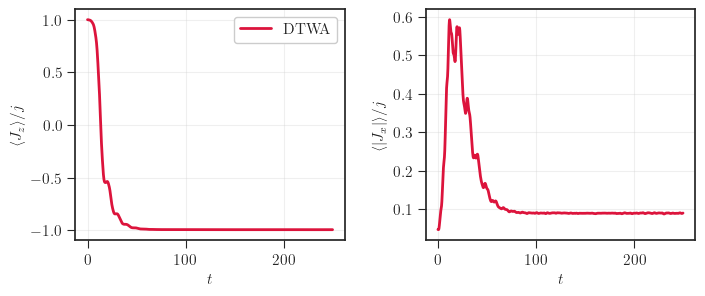

In [16]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

ax[0].plot(results['t_grid'], results['order_params']['mean_jz'], linewidth = 2, label = 'DTWA', color = 'crimson')
ax[0].set_ylabel(r'$\langle J_z \rangle / j$')
ax[0].set_xlabel(r'$t$')
ax[0].grid(alpha = 0.3)
ax[0].legend()

ax[1].plot(results['t_grid'], results['order_params']['rms_jx'], linewidth = 2, label = 'DTWA', color = 'crimson')
ax[1].set_ylabel(r'$\langle |J_x| \rangle / j$')
ax[1].set_xlabel(r'$t$')
ax[1].grid(alpha = 0.3)

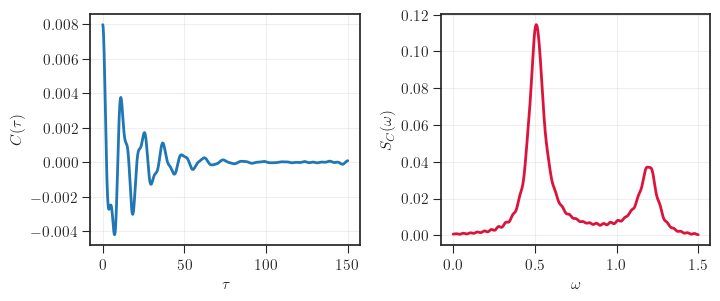

In [17]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

ax[0].plot(results['tau_grid'], results['c_tau'], linewidth = 2)
ax[0].set_ylabel(r'$C(\tau)$')
ax[0].set_xlabel(r'$\tau$')
ax[0].grid(alpha = 0.3)

ax[1].plot(results['w_grid'], results['S_w'], linewidth = 2, color = 'crimson')
ax[1].set_ylabel(r'$S_C(\omega)$')
ax[1].set_xlabel(r'$\omega$')
ax[1].grid(alpha = 0.3)

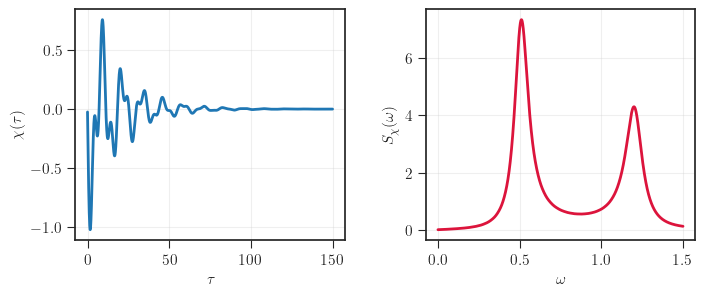

In [18]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

ax[0].plot(results['tau_grid_resp'], results['chi_r_tau'], linewidth = 2)
ax[0].set_ylabel(r'$\chi(\tau)$')
ax[0].set_xlabel(r'$\tau$')
ax[0].grid(alpha = 0.3)

ax[1].plot(results['w_grid'], -results['imag_chi_w'], linewidth = 2, color = 'crimson')
ax[1].set_ylabel(r'$S_{\chi}(\omega)$')
ax[1].set_xlabel(r'$\omega$')
ax[1].grid(alpha = 0.3)

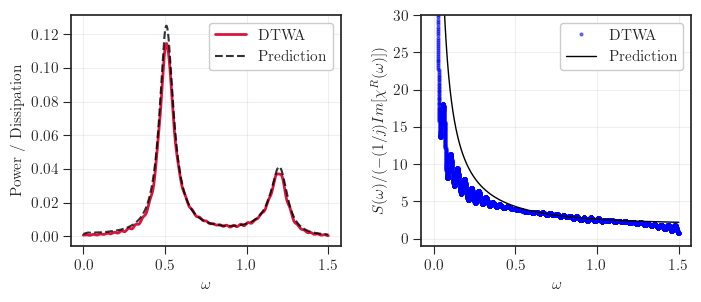

In [19]:
w_grid = results['w_grid']
S_w = results['S_w']
imag_chi_w = results['imag_chi_w'] # This is now cleanly O(1)
j_val = results['j_val']

if T_val < 1e-10:
    thermal_factor = jnp.ones_like(w_grid)
else:
    thermal_factor = 2.0 / jnp.tanh(w_grid / (2.0 * T_val + 1e-15))

# 1. The exact FDT Prediction for collective normalized spins
fdt_prediction = - (1.0 / j_val) * imag_chi_w * thermal_factor

# 2. The Ratio (Divide S_w by the scaled prediction without coth)
scaled_imag_chi = (1.0 / j_val) * imag_chi_w
mask = jnp.abs(scaled_imag_chi) > 1e-5 
ratio = jnp.where(mask, S_w / (-scaled_imag_chi + 1e-12), jnp.nan)

# --- Plotting ---
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

ax[0].plot(w_grid, S_w, label=r'DTWA', color='crimson', lw=2)
ax[0].plot(w_grid, fdt_prediction, '--', label=r'Prediction', color='black', alpha=0.8)
ax[0].legend(loc = 1)
ax[0].set_xlabel(r"$\omega$")
ax[0].set_ylabel("Power / Dissipation")
ax[0].grid(alpha=0.3)

ax[1].plot(w_grid, ratio, 'o', markersize=2, label='DTWA', color='blue', alpha=0.5)
ax[1].plot(w_grid, thermal_factor, '-', label=r'Prediction', color='black', lw=1)
ax[1].set_xlabel(r"$\omega$")
ax[1].legend()
ax[1].set_ylabel(r"$S(\omega) / (-(1/j) Im[\chi^R(\omega)])$")
ax[1].set_ylim(-1, 30) # To clearly see the target line
ax[1].grid(alpha=0.3)
plt.show()

# Phase Transiton

In [24]:
%%capture

temperatures = {"Zero": 1e-6, "Middle": 0.5, "High": 1.5}
g_range = jnp.linspace(0.15, 1.6, 20)
results_by_temp = {}

# 2. Perform the Sweep
for label, T in temperatures.items():
    print(f"Starting sweep for {label} Temperature (T={T})...")
    steady_jz = []
    steady_abs_jx = []

    for g in g_range:
        # Run simulation with the corrected key logic
        sim_key = jax.random.PRNGKey(int(g * 100 + T * 10))
        res = run_dicke_simulation(g, s_val=1.0, T=T, t_max=250, key=sim_key)
        
        # Calculate steady-state (last 10% of the long t_max=250 run)
        n_steps = len(res["dtwa"]["mean_jz"])
        start_idx = int(n_steps * 0.9)
        
        jz_val = jnp.mean(res["dtwa"]["mean_jz"][start_idx:])
        jx_val = jnp.mean(res["dtwa"]["abs_jx"][start_idx:])
        
        steady_jz.append(jz_val)
        steady_abs_jx.append(jx_val)
    
    results_by_temp[label] = {"jz": steady_jz, "jx": steady_abs_jx}

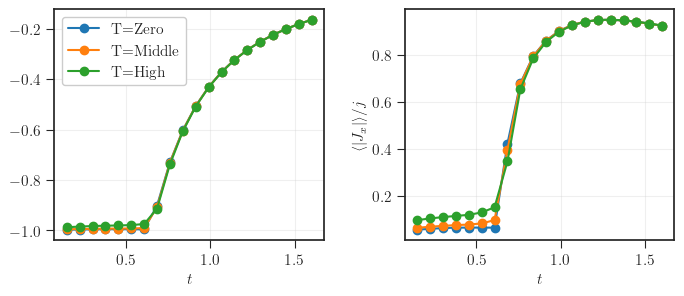

In [25]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

for label, data in results_by_temp.items():
    ax[0].plot(g_range, data["jz"], 'o-', label=f'T={label}')
ax[1].set_ylabel(r'$\langle J_z \rangle / j$')
ax[0].set_xlabel(r'$t$')
ax[0].grid(alpha = 0.3)
ax[0].legend()

for label, data in results_by_temp.items():
    ax[1].plot(g_range, data["jx"], 'o-', label=f'T={label}')
ax[1].set_ylabel(r'$\langle |J_x| \rangle / j$')
ax[1].set_xlabel(r'$t$')
ax[1].grid(alpha = 0.3)